In [131]:

# for package installation
# pip install numpy scipy scikit-learn sounddevice librosa
# folder structure:
# - prototype.ipynb
# - data/
#   - recording1.wav
#   - recording1-events.txt

# note that recording1 has to match in the wav and txt file

import os
import numpy as np
import librosa
from scipy.signal import butter, lfilter, welch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model  import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

EVENT_WINDOW_MARGIN = 0.5
SR = 256
WINDOW_SIZE = 2
SAMPLES_PER_WINDOW = SR * WINDOW_SIZE
DATA_PATH = "data"
CAFFEINE_DATA_PATH = "data_caffeine"

INITIAL_STATE_BEFORE_FIRST_EVENT = 2

MARKER_TO_LABEL = {
    1: 0,  
    2: 1,  
}

DATASET_LABELS = {
    0: "general",
    1: "caffeine_comparison",
    2: "caffeine_baseline"
}

def bandpass(data, low=0.5, high=40, fs=256):
    b, a = butter(4, [low / (fs / 2), high / (fs / 2)], btype="band")
    return lfilter(b, a, data)

def extract_features(signal, sr):

    freqs, psd = welch(signal, sr)

    def band_power(low, high):
        idx = (freqs >= low) & (freqs <= high)
        if not np.any(idx):
            return 0.0
        return np.mean(psd[idx])

    delta = band_power(0.5, 4)
    theta = band_power(4, 8)
    alpha = band_power(8, 12)
    beta = band_power(12, 30)

    alpha_beta_ratio = alpha / (beta + 1e-9)
    alpha_theta_ratio = alpha / (theta + 1e-9)

    total_power = delta + theta + alpha + beta

    theta_beta_ratio = theta / (beta + 1e-9)
    alpha_delta_ratio = alpha / (delta + 1e-9)

    relative_alpha = alpha / (total_power + 1e-9)
    relative_beta = beta / (total_power + 1e-9)

    log_delta = np.log(delta + 1e-9)
    log_theta = np.log(theta + 1e-9)
    log_alpha = np.log(alpha + 1e-9)
    log_beta = np.log(beta + 1e-9)
    log_alpha_beta_ratio = np.log(alpha_beta_ratio + 1e-9)

    return [
        delta,
        theta,
        alpha,
        beta,
        alpha_beta_ratio,
        alpha_theta_ratio,
        theta_beta_ratio,
        alpha_delta_ratio,
        relative_alpha,
        relative_beta,
        log_delta,
        log_theta,
        log_alpha,
        log_beta,
        log_alpha_beta_ratio,
    ]

def load_events(txt_path):
    events = []

    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("#") or line == "":
                continue

            marker, time = line.split(",")
            marker = int(marker.strip())
            time = float(time.strip())
            events.append((marker, time))

    events.sort(key=lambda x: x[1])
    return events

def get_state_at_time(begin, end, middle, events):
    current_state = INITIAL_STATE_BEFORE_FIRST_EVENT
    event_before = None
    event_after = None
    for marker, event_time in events:
        if event_time > begin and event_time < end:
            current_state = 3
            return current_state, event_before, event_after
        elif event_time < begin and (event_time + EVENT_WINDOW_MARGIN) > begin:
            current_state = 3
            return current_state, event_before, event_after
        elif event_time > end and event_time < (end + EVENT_WINDOW_MARGIN):
            current_state = 3
            return current_state, event_before, event_after
        elif event_time <= begin:
            current_state = marker
            event_before = event_time
        elif event_time >= end and event_after is None:
            event_after = event_time
            break
    return current_state, event_before, event_after

def find_txt_for_audio(audio_path):
    base, _ = os.path.splitext(audio_path)
    txt_path = base + "-events.txt"
    return txt_path

X = []
y = []
groups = []

X_caffeine_train = []
y_caffeine_train = []
groups_caffeine_train = []

X_caffeine_comparison = []
y_caffeine_comparison = []
groups_caffeine_comparison = []

X_caffeine_baseline = []
y_caffeine_baseline = []
groups_caffeine_baseline = []
sample_meta_caffeine_baseline = []


sample_meta = []

print("\n--- Load Data ---")
print("Data Path:", DATA_PATH)

all_files = os.listdir(DATA_PATH)
audio_files = [
    f for f in all_files
    if f.lower().endswith((".wav", ".wave"))
]

print("Registered audio-files:", len(audio_files))
print(audio_files)



for file in audio_files:
    audio_path = os.path.join(DATA_PATH, file)
    txt_path = find_txt_for_audio(audio_path)


    signal, sr = librosa.load(audio_path, sr=SR, mono=True)
    duration_sec = len(signal) / SR
    expected_windows = int(len(signal) // SAMPLES_PER_WINDOW)

    signal = bandpass(signal, fs=SR)

    events = load_events(txt_path)
    print("  Events:", events[:10])
    if len(events) > 0:
        print("  First Event at:", events[0][1], "s")
        print("  Last Event at:", events[-1][1], "s")

    samples_before_file = len(y)
    skipped_no_state = 0
    skipped_unknown_marker = 0
    skipped_in_event_window = 0

    for i in range(0, len(signal) - SAMPLES_PER_WINDOW + 1, SAMPLES_PER_WINDOW):
        start_time = i / SR
        end_time = (i + SAMPLES_PER_WINDOW) / SR
        mid_time = (start_time + end_time) / 2

        window = signal[i: i + SAMPLES_PER_WINDOW]
        state, event_before, event_after = get_state_at_time(start_time, end_time, mid_time, events)

        difference_to_nearest_event = 0

        if event_before is not None and event_after is not None:
            difference_to_nearest_event = min(event_before - start_time, event_after - end_time)
        elif event_before is not None:
            difference_to_nearest_event = event_before - start_time
        elif event_after is not None:
            difference_to_nearest_event = event_after - end_time

        if state is None:
            skipped_no_state += 1
            continue

        if state not in MARKER_TO_LABEL:
            if state == 3:
                skipped_in_event_window += 1
            else:
                skipped_unknown_marker += 1
            continue

        label = MARKER_TO_LABEL[state]
        features = extract_features(window, SR)

        dataset_belonging = -1

        meta = {
            "recording": file,
            "start_time": start_time,
            "end_time": end_time,
            "mid_time": mid_time,
            "state": state,
            "label": label,
            "event_before": event_before,
            "event_after": event_after,
            "difference_to_nearest_event": difference_to_nearest_event,
            "dataset_belonging": dataset_belonging
        }

        if file.startswith("caffeine-comparison-"):
            X_caffeine_comparison.append(features)
            y_caffeine_comparison.append(label)
            groups_caffeine_comparison.append(file)
            dataset_belonging = 1
        elif not file.startswith("caffeine-baseline-"):
            X_caffeine_train.append(features)
            y_caffeine_train.append(label)
            groups_caffeine_train.append(file)
            dataset_belonging = 0
        
        if file.startswith("caffeine-baseline-"):
            X_caffeine_baseline.append(features)
            y_caffeine_baseline.append(label)
            groups_caffeine_baseline.append(file)
            dataset_belonging = 2
            sample_meta_caffeine_baseline.append({
                "recording": file,
                "start_time": start_time,
                "end_time": end_time,
                "mid_time": mid_time,
                "state": state,
                "label": label,
                "event_before": event_before,
                "event_after": event_after,
                "difference_to_nearest_event": difference_to_nearest_event,
                "dataset_belonging": dataset_belonging
            })
        else:
            X.append(features)
            y.append(label)
            groups.append(file)
            sample_meta.append(meta)
            

    print("   Skipped windows with no state: ", skipped_no_state, " Skipped windows with unknown marker: ", skipped_unknown_marker, " Skipped windows in event window: ", skipped_in_event_window)
    samples_after_file = len(y)
    created_for_file = samples_after_file - samples_before_file
X = np.array(X)
y = np.array(y)
print("\n--- Total ---")
print("Total Samples", len(y))

"""X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)"""

X_train, X_test, y_train, y_test, sample_meta_train, sample_meta_test = train_test_split(
    X,
    y,
    sample_meta,
    test_size=0.25,
    stratify=y,
    random_state=42,
)
print("Train samples:", len(y_train))
print("Test samples:", len(y_test))


--- Load Data ---
Data Path: data
Registered audio-files: 28
['BYB_Recording_2026-04-22_14.00.24.wav', 'BYB_Recording_2026-04-22_14.19.14.wav', 'BYB_Recording_2026-04-22_14.22.45.wav', 'BYB_Recording_2026-04-22_14.25.10.wav', 'BYB_Recording_2026-05-27_11.48.00.wav', 'BYB_Recording_2026-05-27_11.51.32.wav', 'BYB_Recording_2026-05-27_11.54.47.wav', 'BYB_Recording_2026-05-27_11.58.10.wav', 'BYB_Recording_2026-05-27_12.08.32.wav', 'BYB_Recording_2026-05-27_12.13.53.wav', 'BYB_Recording_2026-05-27_12.16.46.wav', 'BYB_Recording_2026-05-27_12.19.29.wav', 'BYB_Recording_2026-05-31_18.16.43.wav', 'BYB_Recording_2026-05-31_18.20.54.wav', 'BYB_Recording_2026-05-31_18.27.46.wav', 'BYB_Recording_2026-05-31_18.31.47.wav', 'BYB_Recording_2026-05-31_18.34.44.wav', 'BYB_Recording_2026-05-31_18.37.41.wav', 'BYB_Recording_2026-05-31_18.40.47.wav', 'BYB_Recording_2026-05-31_18.43.35.wav', 'BYB_Recording_2026-05-31_18.46.17.wav', 'BYB_Recording_2026-05-31_18.48.45.wav', 'caffeine-baseline-BYB_Recording_20

In [132]:
"""from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np

groups = np.array(groups)

logo = LeaveOneGroupOut()

all_results = []

print("\n==============================")
print("Leave-One-Recording-Out Test")
print("==============================")

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    X_train_logo = X[train_idx]
    X_test_logo = X[test_idx]

    y_train_logo = y[train_idx]
    y_test_logo = y[test_idx]

    train_recordings = np.unique(groups[train_idx])
    test_recording = np.unique(groups[test_idx])[0]

    model_logo = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=6,
        min_samples_leaf=4,
        min_samples_split=8,
        max_features="sqrt",
        random_state=42,
    )

    model_logo.fit(X_train_logo, y_train_logo)

    y_pred_logo = model_logo.predict(X_test_logo)

    acc = accuracy_score(y_test_logo, y_pred_logo)
    bal_acc = balanced_accuracy_score(y_test_logo, y_pred_logo)
    cm = confusion_matrix(y_test_logo, y_pred_logo)

    all_results.append({
        "fold": fold,
        "test_recording": test_recording,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "support": len(y_test_logo),
    })

    print("\n------------------------------")
    print(f"Fold {fold}")
    print("Test Recording:", test_recording)
    print("Train Recordings:", len(train_recordings))
    print("Test Samples:", len(y_test_logo))
    print("Accuracy:", acc)
    print("Balanced Accuracy:", bal_acc)
    print("Confusion Matrix:")
    print(cm)

    print(classification_report(
        y_test_logo,
        y_pred_logo,
        target_names=["Eyes open", "Eyes closed"],
        zero_division=0
    ))

accuracies = [r["accuracy"] for r in all_results]
balanced_accuracies = [r["balanced_accuracy"] for r in all_results]

print("\n==============================")
print("LORO Summary")
print("==============================")
print("Mean Accuracy:", np.mean(accuracies))
print("Std Accuracy:", np.std(accuracies))
print("Mean Balanced Accuracy:", np.mean(balanced_accuracies))
print("Std Balanced Accuracy:", np.std(balanced_accuracies))

print("\nPer Recording Results:")
for r in all_results:
    print(
        f"{r['test_recording']} | "
        f"Accuracy: {r['accuracy']:.3f} | "
        f"Balanced Accuracy: {r['balanced_accuracy']:.3f} | "
        f"Support: {r['support']}"
    )"""

'from sklearn.model_selection import LeaveOneGroupOut\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix\nimport numpy as np\n\ngroups = np.array(groups)\n\nlogo = LeaveOneGroupOut()\n\nall_results = []\n\nprint("\n==============================")\nprint("Leave-One-Recording-Out Test")\nprint("==============================")\n\nfor fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):\n    X_train_logo = X[train_idx]\n    X_test_logo = X[test_idx]\n\n    y_train_logo = y[train_idx]\n    y_test_logo = y[test_idx]\n\n    train_recordings = np.unique(groups[train_idx])\n    test_recording = np.unique(groups[test_idx])[0]\n\n    model_logo = RandomForestClassifier(\n        n_estimators=300,\n        class_weight="balanced",\n        max_depth=6,\n        min_samples_leaf=4,\n        min_samples_split=8,\n        max_features="sqrt",\n        random_state=

In [133]:
"""from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, class_weight = "balanced")

param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [2,4,6,8],
    "min_samples_split": [2, 3, 4, 6],
    "min_samples_leaf": [2, 3, 4, 6],
    "max_features": ["sqrt", "log2", None]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print("CV score:", search.best_score_)

final_model = search.best_estimator_
print("Test score:", final_model.score(X_test, y_test))

"""
"""{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 8}
CV score: 0.9089820359281436
Test score: 0.9330143540669856"""

"{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 8}\nCV score: 0.9089820359281436\nTest score: 0.9330143540669856"

In [134]:
"""model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=6,
    min_samples_leaf=4,
    min_samples_split=8,
    max_features="sqrt",
    random_state=42,
)"""





'model = RandomForestClassifier(\n    n_estimators=300,\n    class_weight="balanced",\n    max_depth=6,\n    min_samples_leaf=4,\n    min_samples_split=8,\n    max_features="sqrt",\n    random_state=42,\n)'

In [135]:
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Linear Regression model (baseline)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin_reg = lin_reg.predict(X_test)
y_pred_lin_cls = (y_pred_lin_reg >= 0.5).astype(int)

# 2. XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=8,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    random_state=42,
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 3. Dictionary to store all models
models = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=200, random_state=42),
}

# Train and evaluate all models
results = {}
print("\n" + "=" * 70)
print("COMPARISON OF ALL CLASSIFICATION MODELS")
print("=" * 70 + "\n")

for model_name, model in models.items():
    print(f"\n{model_name}")
    print("-" * 50)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[model_name] = acc
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"Classification report:\n{classification_report(y_test, y_pred)}")

# Add Linear Regression and XGBoost to results
all_results = results.copy()
all_results["Linear Regression"] = accuracy_score(y_test, y_pred_lin_cls)
all_results["XGBoost"] = accuracy_score(y_test, y_pred_xgb)
all_results["Random Forest"] = accuracy_score(y_test, y_pred_rf)


print("\n" + "=" * 70)
print("ACCURACY SUMMARY")
print("=" * 70)
sorted_results = sorted(all_results.items(), key=lambda x: x[1], reverse=True)
for i, (model_name, acc) in enumerate(sorted_results, 1):
    print(f"{i}. {model_name:30s}: {acc:.4f}")



COMPARISON OF ALL CLASSIFICATION MODELS


Gradient Boosting
--------------------------------------------------
Accuracy: 0.8838
Confusion matrix:
[[175  21]
 [ 22 152]]
Classification report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       196
           1       0.88      0.87      0.88       174

    accuracy                           0.88       370
   macro avg       0.88      0.88      0.88       370
weighted avg       0.88      0.88      0.88       370


AdaBoost
--------------------------------------------------
Accuracy: 0.8865
Confusion matrix:
[[166  30]
 [ 12 162]]
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       196
           1       0.84      0.93      0.89       174

    accuracy                           0.89       370
   macro avg       0.89      0.89      0.89       370
weighted avg       0.89      0.89      0.89       370


SVM (RBF)


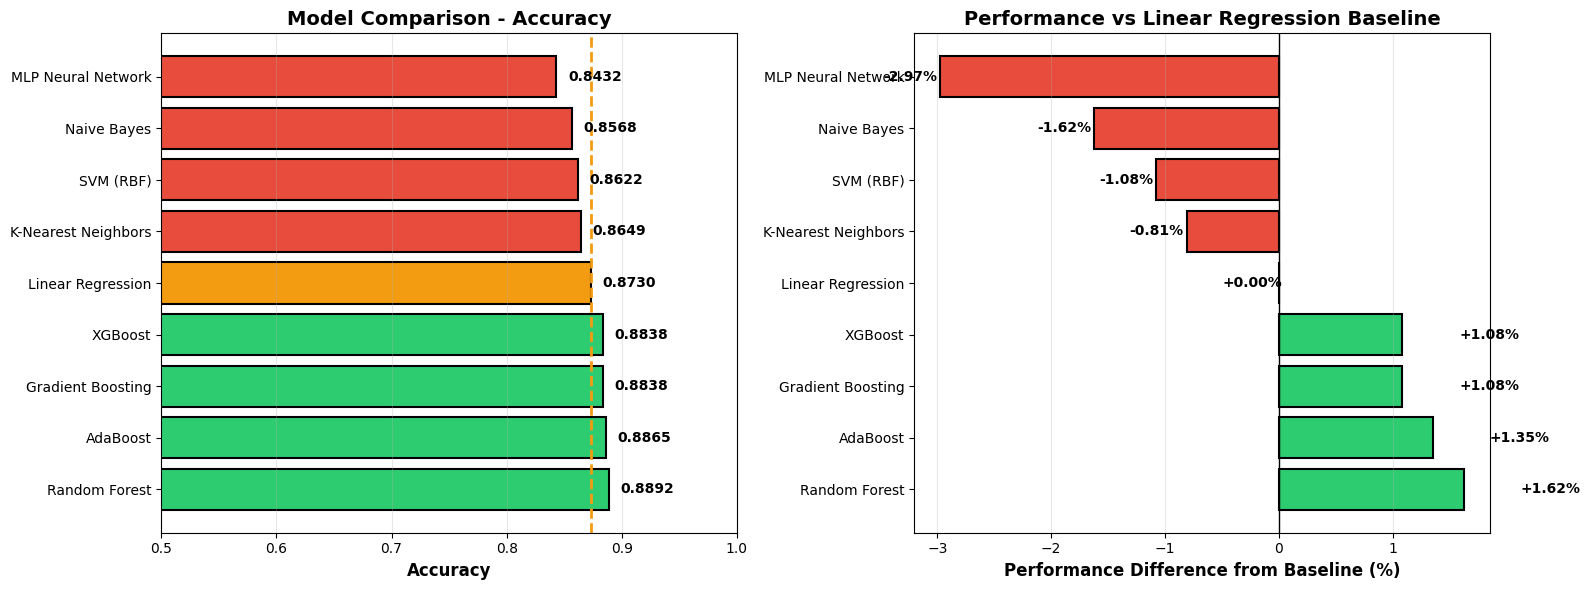


MODEL PERFORMANCE SUMMARY vs LINEAR REGRESSION BASELINE

Baseline (Linear Regression) Accuracy: 0.8730

Model Rankings:
 1. Random Forest                 : 0.8892 (+1.62%) ↑ BETTER
 2. AdaBoost                      : 0.8865 (+1.35%) ↑ BETTER
 3. Gradient Boosting             : 0.8838 (+1.08%) ↑ BETTER
 4. XGBoost                       : 0.8838 (+1.08%) ↑ BETTER
 5. Linear Regression             : 0.8730 (+0.00%) = SAME
 6. K-Nearest Neighbors           : 0.8649 (-0.81%) ↓ WORSE
 7. SVM (RBF)                     : 0.8622 (-1.08%) ↓ WORSE
 8. Naive Bayes                   : 0.8568 (-1.62%) ↓ WORSE
 9. MLP Neural Network            : 0.8432 (-2.97%) ↓ WORSE


In [136]:
import matplotlib.pyplot as plt

# Create comprehensive comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by accuracy
sorted_models = sorted(all_results.items(), key=lambda x: x[1], reverse=True)
model_names = [name for name, _ in sorted_models]
accuracies = [acc for _, acc in sorted_models]

# Baseline (Linear Regression)
baseline_acc = all_results["Linear Regression"]

# Color coding: baseline in orange, better models in green, worse in red
colors = []
for acc in accuracies:
    if acc > baseline_acc:
        colors.append('#2ecc71')  # Green for better
    elif acc == baseline_acc:
        colors.append('#f39c12')  # Orange for baseline
    else:
        colors.append('#e74c3c')  # Red for worse

# Plot 1: Bar chart with absolute accuracy
ax1 = axes[0]
bars = ax1.barh(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.axvline(baseline_acc, color='#f39c12', linestyle='--', linewidth=2, label='Baseline (Linear Regression)')
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison - Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlim([0.5, 1.0])
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax1.text(acc + 0.01, i, f'{acc:.4f}', va='center', fontweight='bold')

# Plot 2: Performance difference from baseline
ax2 = axes[1]
performance_diff = [(acc - baseline_acc) * 100 for acc in accuracies]
colors_diff = ['#2ecc71' if diff > 0 else ('#f39c12' if diff == 0 else '#e74c3c') for diff in performance_diff]

bars2 = ax2.barh(model_names, performance_diff, color=colors_diff, edgecolor='black', linewidth=1.5)
ax2.axvline(0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Performance Difference from Baseline (%)', fontsize=12, fontweight='bold')
ax2.set_title('Performance vs Linear Regression Baseline', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, diff) in enumerate(zip(bars2, performance_diff)):
    ax2.text(diff + (0.5 if diff > 0 else -0.5), i, f'{diff:+.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_luka.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("MODEL PERFORMANCE SUMMARY vs LINEAR REGRESSION BASELINE")
print("=" * 70)
print(f"\nBaseline (Linear Regression) Accuracy: {baseline_acc:.4f}")
print("\nModel Rankings:")
for i, (name, acc) in enumerate(sorted_models, 1):
    diff = (acc - baseline_acc) * 100
    status = "↑ BETTER" if diff > 0 else ("= SAME" if diff == 0 else "↓ WORSE")
    print(f"{i:2d}. {name:30s}: {acc:.4f} ({diff:+.2f}%) {status}")


In [137]:
feature_names = [
    "delta",
    "theta",
    "alpha",
    "beta",
    "alpha_beta_ratio",
    "alpha_theta_ratio",
    "theta_beta_ratio",
    "alpha_delta_ratio",
    "relative_alpha",
    "relative_beta",
    "log_delta",
    "log_theta",
    "log_alpha",
    "log_beta",
    "log_alpha_beta_ratio",
]

In [138]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

                 feature  importance
8         relative_alpha    0.244877
7      alpha_delta_ratio    0.152897
12             log_alpha    0.145664
5      alpha_theta_ratio    0.124397
4       alpha_beta_ratio    0.086838
14  log_alpha_beta_ratio    0.084073
13              log_beta    0.032253
11             log_theta    0.030303
9          relative_beta    0.030049
10             log_delta    0.028755
6       theta_beta_ratio    0.025591
2                  alpha    0.008975
0                  delta    0.004152
1                  theta    0.000994
3                   beta    0.000183


In [139]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_importance)

                 feature  importance_mean  importance_std
4       alpha_beta_ratio         0.077928        0.013094
7      alpha_delta_ratio         0.044505        0.016846
6       theta_beta_ratio         0.025946        0.009507
5      alpha_theta_ratio         0.007838        0.008946
13              log_beta         0.000450        0.004473
2                  alpha         0.000000        0.000000
1                  theta         0.000000        0.000000
3                   beta         0.000000        0.000000
0                  delta         0.000000        0.000000
9          relative_beta         0.000000        0.000000
12             log_alpha        -0.000180        0.004005
11             log_theta        -0.001261        0.002390
8         relative_alpha        -0.001622        0.002377
10             log_delta        -0.004324        0.004915
14  log_alpha_beta_ratio        -0.013423        0.006855


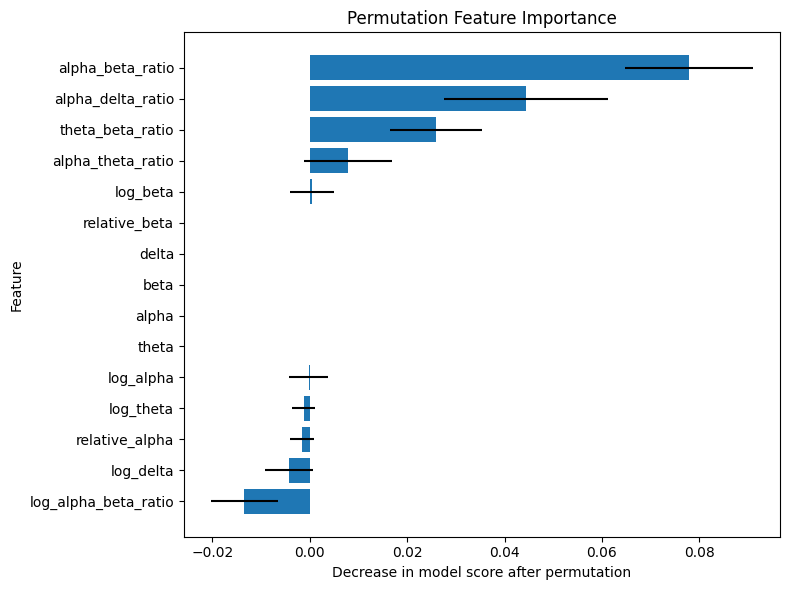

In [140]:
import matplotlib.pyplot as plt

plot_data = perm_importance.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_std"]
)
plt.xlabel("Decrease in model score after permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

In [141]:
"""# Better threshhold 

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    proba = model.predict_proba(X_test)
    p_eyes_closed = proba[:, 1]

    y_pred_thr = (p_eyes_closed >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print("Accuracy:", accuracy_score(y_test, y_pred_thr))
    print(confusion_matrix(y_test, y_pred_thr))
    print(classification_report(
        y_test,
        y_pred_thr,
        target_names=["Closed", "Open"]
    ))"""

'# Better threshhold \n\nfrom sklearn.metrics import classification_report, confusion_matrix, accuracy_score\n\nfor threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:\n    proba = model.predict_proba(X_test)\n    p_eyes_closed = proba[:, 1]\n\n    y_pred_thr = (p_eyes_closed >= threshold).astype(int)\n\n    print("\nThreshold:", threshold)\n    print("Accuracy:", accuracy_score(y_test, y_pred_thr))\n    print(confusion_matrix(y_test, y_pred_thr))\n    print(classification_report(\n        y_test,\n        y_pred_thr,\n        target_names=["Closed", "Open"]\n    ))'

In [142]:

train_pred = rf_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_acc)
print("Training Classification Report:")
print(classification_report(y_train, train_pred, target_names=["Closed", "Open"]))


proba = rf_model.predict_proba(X_test)
p_eyes_closed = proba[:, 1]
threshold = 0.5
y_pred = (p_eyes_closed >= threshold).astype(int)
test_acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_acc)
print("Test Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Closed", "Open"]))

Training Accuracy: 0.9584837545126353
Training Classification Report:
              precision    recall  f1-score   support

      Closed       0.98      0.94      0.96       588
        Open       0.94      0.97      0.96       520

    accuracy                           0.96      1108
   macro avg       0.96      0.96      0.96      1108
weighted avg       0.96      0.96      0.96      1108

Test Accuracy: 0.8891891891891892
Test Classification Report:
              precision    recall  f1-score   support

      Closed       0.91      0.87      0.89       196
        Open       0.86      0.91      0.89       174

    accuracy                           0.89       370
   macro avg       0.89      0.89      0.89       370
weighted avg       0.89      0.89      0.89       370



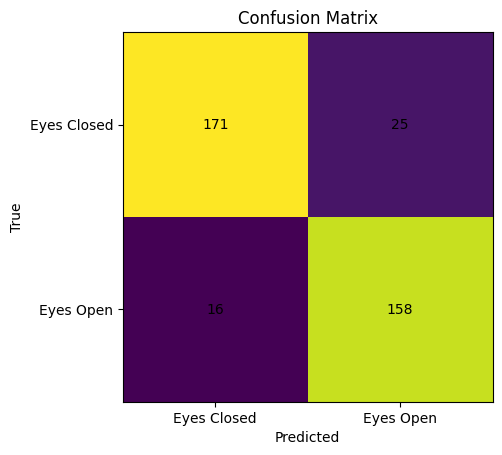

In [143]:
import matplotlib.pyplot as plt
import numpy as np
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    fig, ax = plt.subplots()

    im = ax.imshow(cm)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Eyes Closed", "Eyes Open"])
    ax.set_yticklabels(["Eyes Closed", "Eyes Open"])

    plt.show()

plot_confusion_matrix(y_test, y_pred)

In [144]:
groups_caffeine = []
X_caffeine = []
y_caffeine = []

print("\n--- Load Data ---")
print("Data Path:", CAFFEINE_DATA_PATH)

all_files = os.listdir(CAFFEINE_DATA_PATH)
audio_files = [
    f for f in all_files
    if f.lower().endswith((".wav", ".wave"))
]

print("Registered audio-files:", len(audio_files))
print(audio_files)

for file in audio_files:
    audio_path = os.path.join(CAFFEINE_DATA_PATH, file)
    txt_path = find_txt_for_audio(audio_path)


    signal, sr = librosa.load(audio_path, sr=SR, mono=True)
    duration_sec = len(signal) / SR
    expected_windows = int(len(signal) // SAMPLES_PER_WINDOW)

    signal = bandpass(signal, fs=SR)

    events = load_events(txt_path)
    print("  Events:", events[:10])
    if len(events) > 0:
        print("  First Event at:", events[0][1], "s")
        print("  Last Event at:", events[-1][1], "s")

    samples_before_file = len(y_caffeine)
    skipped_no_state = 0
    skipped_unknown_marker = 0
    skipped_in_event_window = 0

    for i in range(0, len(signal) - SAMPLES_PER_WINDOW + 1, SAMPLES_PER_WINDOW):
        start_time = i / SR
        end_time = (i + SAMPLES_PER_WINDOW) / SR
        mid_time = (start_time + end_time) / 2

        window = signal[i:i + SAMPLES_PER_WINDOW]
        state, event_before, event_after = get_state_at_time(start_time, end_time, mid_time, events)

        if state is None:
            skipped_no_state += 1
            continue

        if state not in MARKER_TO_LABEL:
            if state == 3:
                skipped_in_event_window += 1
            else:
                skipped_unknown_marker += 1
            continue
        
        label = MARKER_TO_LABEL[state]
        features = extract_features(window, SR)

        X_caffeine.append(features)
        y_caffeine.append(label)
        groups_caffeine.append(file)

    print("   Skipped windows with no state: ", skipped_no_state, " Skipped windows with unknown marker: ", skipped_unknown_marker, " Skipped windows in event window: ", skipped_in_event_window)
    samples_after_file = len(y_caffeine)
    created_for_file = samples_after_file - samples_before_file

"""X_caffeine = np.array(X_caffeine)
y_caffeine = np.array(y_caffeine)"""


print("Total samples:", len(y_caffeine))


--- Load Data ---
Data Path: data_caffeine
Registered audio-files: 3
['caffeine-baseline-BYB_Recording_2026-05-27_13.07.49.wav', 'caffeine-baseline-BYB_Recording_2026-05-27_13.14.32.wav', 'caffeine-baseline-BYB_Recording_2026-05-27_13.16.57.wav']
  Events: [(1, 10.4998), (2, 30.6284), (1, 50.0618), (2, 70.4654), (1, 90.191), (2, 115.256)]
  First Event at: 10.4998 s
  Last Event at: 115.256 s
   Skipped windows with no state:  0  Skipped windows with unknown marker:  0  Skipped windows in event window:  10
  Events: [(1, 10.311), (2, 30.3498), (1, 40.2284), (2, 60.4094), (1, 72.4876), (2, 100.2114), (1, 110.6804), (2, 131.4978)]
  First Event at: 10.311 s
  Last Event at: 131.4978 s
   Skipped windows with no state:  0  Skipped windows with unknown marker:  0  Skipped windows in event window:  14
  Events: [(1, 11.0348), (2, 30.376), (1, 49.4674), (2, 70.2558), (1, 85.8104), (2, 108.4526), (1, 120.3168), (2, 140.2392)]
  First Event at: 11.0348 s
  Last Event at: 140.2392 s
   Skipped

In [145]:
model_caffeine = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=8,
    min_samples_leaf=2,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
)
model_caffeine.fit(X_caffeine_train, y_caffeine_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [146]:
print(X_caffeine)

caffeine_pred = model_caffeine.predict(X_caffeine)
caffeine_acc = accuracy_score(y_caffeine, caffeine_pred)

print("Caffeine Accuracy:", caffeine_acc)
print("Caffeine Classification Report:")
print(classification_report(y_caffeine, caffeine_pred, target_names=["Closed", "Open"]))

[[np.float64(6.86319939587864e-07), np.float64(3.464859847267192e-07), np.float64(1.5993424000466978e-07), np.float64(5.686057302127699e-08), np.float64(2.7641316297689857), np.float64(0.46026098039738284), np.float64(5.988291623024652), np.float64(0.23269256541658137), np.float64(0.12788593132031778), np.float64(0.04546660762586313), np.float64(-14.190465947763082), np.float64(-14.872541504476581), np.float64(-15.64227000257518), np.float64(-16.665229633865074), np.float64(1.0167265280598157)], [np.float64(5.87287307361486e-07), np.float64(3.1988994715430935e-07), np.float64(2.3552766719728146e-07), np.float64(6.721904397623852e-08), np.float64(3.452520784069013), np.float64(0.7339826918417642), np.float64(4.689159045760459), np.float64(0.40036163325304647), np.float64(0.19450244100438455), np.float64(0.05551054061265873), np.float64(-14.346050390420958), np.float64(-14.952167616356798), np.float64(-15.257200649821739), np.float64(-16.500542073888194), np.float64(1.2391046265783405)],

In [147]:
caffeine_comparison_pred = model_caffeine.predict(X_caffeine_comparison)
caffeine_comparison_acc = accuracy_score(y_caffeine_comparison, caffeine_comparison_pred)

print("Caffeine Comparison Accuracy:", caffeine_comparison_acc)
print("Caffeine Comparison Classification Report:")
print(classification_report(y_caffeine_comparison, caffeine_comparison_pred, target_names=["Closed", "Open"]))

Caffeine Comparison Accuracy: 0.9389671361502347
Caffeine Comparison Classification Report:
              precision    recall  f1-score   support

      Closed       0.93      0.94      0.94       102
        Open       0.95      0.94      0.94       111

    accuracy                           0.94       213
   macro avg       0.94      0.94      0.94       213
weighted avg       0.94      0.94      0.94       213



In [148]:
import pandas as pd

meta_df = pd.DataFrame(sample_meta)

proba_all = model.predict_proba(X)

meta_df["p_augen_auf"] = proba_all[:, 0]
meta_df["p_augen_zu"] = proba_all[:, 1]
meta_df["pred"] = model.predict(X)
meta_df["confidence"] = np.max(proba_all, axis=1)
meta_df["uncertainty"] = 1 - meta_df["confidence"]

display(meta_df.head())

,recording,start_time,end_time,mid_time,state,label,event_before,event_after,difference_to_nearest_event,dataset_belonging,p_augen_auf,p_augen_zu,pred,confidence,uncertainty
0,BYB_Recording_2026-04-22_14.00.24.wav,0.0,2.0,1.0,2,1,NaN,3.1186,1.1186,-1,0.782062,2.179379e-01,0,0.782062,2.179379e-01
1,BYB_Recording_2026-04-22_14.00.24.wav,4.0,6.0,5.0,1,0,3.1186,48.5822,-0.8814,-1,1.000000,2.916814e-11,0,1.000000,2.916811e-11
2,BYB_Recording_2026-04-22_14.00.24.wav,6.0,8.0,7.0,1,0,3.1186,48.5822,-2.8814,-1,0.997659,2.340519e-03,0,0.997659,2.340519e-03
3,BYB_Recording_2026-04-22_14.00.24.wav,8.0,10.0,9.0,1,0,3.1186,48.5822,-4.8814,-1,1.000000,1.593024e-09,0,1.000000,1.593024e-09
4,BYB_Recording_2026-04-22_14.00.24.wav,10.0,12.0,11.0,1,0,3.1186,48.5822,-6.8814,-1,0.994058,5.942470e-03,0,0.994058,5.942470e-03


In [149]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV



# 1. Create the Linear Regression model
lin_reg = LinearRegression()

# 2. Fit (train) on the same training data
lin_reg.fit(X_train, y_train)

# 3. Predict continuous outputs on the test set
y_pred_reg = lin_reg.predict(X_test)

# 4. Optionally, compute a regression metric (MSE)
mse = mean_squared_error(y_test, y_pred_reg)
print("Linear Regression MSE:", mse)

# 5. Turn continuous outputs into class predictions (0 or 1) by thresholding at 0.5
y_pred_lin_cls = (y_pred_reg >= 0.5).astype(int)

# 6. Evaluate as a classifier
print("Linear Regression (thresholded) Accuracy:", accuracy_score(y_test, y_pred_lin_cls))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lin_cls))
print("Classification report:\n", classification_report(y_test, y_pred_lin_cls))

Linear Regression MSE: 0.08672637729216884
Linear Regression (thresholded) Accuracy: 0.8729729729729729
Confusion matrix:
 [[166  30]
 [ 17 157]]
Classification report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88       196
           1       0.84      0.90      0.87       174

    accuracy                           0.87       370
   macro avg       0.87      0.87      0.87       370
weighted avg       0.88      0.87      0.87       370



In [150]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)
dummy_acc = accuracy_score(y_test, dummy_pred)

print("Dummy Baseline Accuracy:", dummy_acc)
print(classification_report(
    y_test,
    dummy_pred,
    target_names=["Augen AUF", "Augen ZU"]
))

Dummy Baseline Accuracy: 0.5297297297297298
              precision    recall  f1-score   support

   Augen AUF       0.53      1.00      0.69       196
    Augen ZU       0.00      0.00      0.00       174

    accuracy                           0.53       370
   macro avg       0.26      0.50      0.35       370
weighted avg       0.28      0.53      0.37       370



c:\Users\lucav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [151]:
import numpy as np
import pandas as pd

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

wrong_idx = np.where(y_pred != y_test)[0]

wrong_cases = pd.DataFrame(X_test[wrong_idx], columns=feature_names)

wrong_cases["true_label"] = np.asarray(y_test)[wrong_idx]
wrong_cases["predicted_label"] = y_pred[wrong_idx]
wrong_cases["predicted_probability"] = np.max(y_proba[wrong_idx], axis=1)
#wrong_cases["meta"] = np.asarray(sample_meta_test)[wrong_idx]

#unpack samplemeta

wrong_cases["difference_to_nearest_event"] = [m["difference_to_nearest_event"] for m in np.asarray(sample_meta_test)[wrong_idx]]

wrong_cases = wrong_cases.sort_values(
    "predicted_probability",
    ascending=False
)

wrong_cases.head()

,delta,theta,alpha,beta,alpha_beta_ratio,alpha_theta_ratio,theta_beta_ratio,alpha_delta_ratio,relative_alpha,relative_beta,log_delta,log_theta,log_alpha,log_beta,log_alpha_beta_ratio,true_label,predicted_label,predicted_probability,difference_to_nearest_event
28,7.792558e-07,2.395641e-07,3.568988e-07,1.615615e-07,2.195469,1.483591,1.473683,0.457412,0.232012,0.105027,-14.063644,-15.240279,-14.843016,-15.632210,0.786396,0,1,0.931086,-9.5624
0,4.498966e-07,1.296035e-07,3.800723e-07,2.770547e-07,1.366898,2.910124,0.466108,0.842926,0.307098,0.223860,-14.612028,-15.851100,-14.780277,-15.095448,0.312544,0,1,0.872849,-5.9290
29,3.607436e-08,6.442267e-08,1.474881e-07,6.229718e-08,2.330089,2.254388,1.017781,3.978169,0.473808,0.200131,-17.110340,-16.542397,-15.722761,-16.575425,0.845907,1,0,0.870753,-13.4178
35,4.253575e-07,7.647856e-08,3.432319e-07,3.118270e-07,1.097194,4.430024,0.244476,0.805033,0.296427,0.269305,-14.667988,-16.373265,-14.881950,-14.977616,0.092756,0,1,0.870324,-10.8476
22,1.215005e-08,1.253529e-07,2.292750e-07,4.323904e-08,5.182641,1.814560,2.833537,17.435299,0.557824,0.105200,-18.146840,-15.884187,-15.283991,-16.933658,1.645315,1,0,0.870224,-7.4178
